## `photoz_bias.ipynb`

-----------------------

This notebook measures and models the photoz galaxy bias given scale cuts.

In [30]:
import numpy as np
import json
import importlib
import matplotlib.pyplot as plt
import scipy.interpolate as interp
import scipy.optimize as opt
import pyccl as ccl

from pathlib import Path

import src.statistics.inference as inference
import src.statistics.corrfiles as cf
import src.statistics.cosmotools as ct
import src.statistics.combination as comb
import src.statistics.sgp as sgp

import src.analysis.plots as plots

PAPER_FIGURES_ROOT = Path(
    "/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/"
)
pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)

ROOT = cf.get_base_dir()

In [31]:
bins_hsc = np.arange(0.3, 1.8, 0.3)

markers = ["x", "s", "^", "D"]
linestyles = ["-", "--", "-.", ":"]
colormaps = [plt.get_cmap(c) for c in ["Reds", "Blues", "Greens", "Purples"]]
colors = [cmap(0.8) for cmap in colormaps]
tracers_dr1 = ["BGS_ANY", "LRG", "QSO"]  #'ELG_LOPnotqso',
tracers_dr2 = ["BGS_ANY", "LRG", "ELGnotqso", "QSO"]
tracers = ["BGS_ANY", "LRG", "ELGnotqso", "QSO"]  #'ELG_LOPnotqso',
tracer_trad = {
    "BGS_ANY": "BGS",
    "LRG": "LRG",
    "ELGnotqso": "ELG",
    #'ELG_LOPnotqso' : 'ELG-LOP',
    "QSO": "QSO",
}

version = "vF"
CORR_ROOT = ROOT / "src" / "statistics" / "outputs"

In [33]:
stem = "calibration"
path_dictionary = {
    "dr1": {
        "HSC": CORR_ROOT / stem / f"autos_HSC",
        "DESI_NGC": CORR_ROOT / stem / "dr1" / f"autos_NGC",
        "DESI_SGC": CORR_ROOT / stem / "dr1" / f"autos_SGC",
        "DESIxHSC": CORR_ROOT / stem / "dr1" / f"cross",
    },
    "dr2": {
        "HSC": CORR_ROOT / stem / f"autos_HSC",
        "DESI_NGC": CORR_ROOT / stem / "dr2" / f"autos_NGC",
        "DESI_SGC": CORR_ROOT / stem / "dr2" / f"autos_SGC",
        "DESIxHSC": CORR_ROOT / stem / "dr2" / f"cross",
    },
}
assert all([pv.exists() for p in path_dictionary.values() for pv in p.values()])

fr_dr1 = cf.CorrFileReader(path_dictionary["dr1"]["DESIxHSC"])
fr_dr2 = cf.CorrFileReader(path_dictionary["dr2"]["DESIxHSC"])
bins_hsc = fr_dr1.get_bins("HSC")
bhsc_vals = (bins_hsc[1:] + bins_hsc[:-1]) / 2
scale_cut = [0.3, 3]
patches = [1, 2, 3, 4]

print("Scale cut :", scale_cut)

Scale cut : [0.3, 3]


In [ ]:
importlib.reload(inference)

results = {}

for bp, bhsc_z in enumerate(bhsc_vals, start=1):
    results[bp] = {t: [] for t in set(tracers)}
    print(f"\n Tomo bin {bp} at z {bhsc_z} \n")
    if bhsc_z < 0.9:
        for t in tracers_dr1:
            bins_tracer = fr_dr1.get_bins(t)
            bins_vals = (bins_tracer[1:] + bins_tracer[:-1]) / 2
            for bs, bt_z in enumerate(bins_vals, start=1):
                zloc = bt_z
                # for some tracer / bhsc combinations, no compute_npz exists. In that case, continue
                files = fr_dr1.get_file(bs, bp, t, "HSC", moc=None)
                if all(not Path(file).exists() for file in files):
                    # print(f'skipping {bs:.3f}, {bp:.3f}, {t}, dr1')
                    nz, nz_err = 0, 0
                else:
                    print(
                        f"Processing {bs} (z:{bt_z:.2f}), {bp} (z:{bhsc_z:.2f}), {t} : (zloc: {zloc}), dr1"
                    )
                    nz, nz_err = inference.compute_npz(
                        path_dictionary=path_dictionary["dr1"],
                        tracer=t,
                        fine_bin=bs,
                        tomo_bin=bp,
                        which_patches=patches,
                        scale_cuts=scale_cut,
                        do_phot_correction=False,
                        do_spec_correction=True,
                        correct_for_wdm=False,  # we do wsp/sqrt(wss) so no need to correct for wdm evolution here
                    )
                results[bp][t].append((zloc, nz, nz_err))
    else:
        for t in tracers_dr2:
            bins_tracer = fr_dr2.get_bins(t)
            bins_vals = (bins_tracer[1:] + bins_tracer[:-1]) / 2
            for bs, bt_z in enumerate(bins_vals, start=1):
                # for some tracer / bhsc combinations, no compute_npz exists. In that case, continue
                files = fr_dr2.get_file(bs, bp, t, "HSC", moc=None)
                zloc = bt_z
                if all(not Path(file).exists() for file in files):
                    # print(f'skipping {bs:.3f}, {bp:.3f}, {t}, dr2')
                    nz, nz_err = 0, 0
                else:
                    print(f"Processing {bs:.3f}, {bp:.3f}, {t} : (zloc: {zloc}), dr2")
                    nz, nz_err = inference.compute_npz(
                        path_dictionary=path_dictionary["dr2"],
                        tracer=t,
                        fine_bin=bs,
                        tomo_bin=bp,
                        which_patches=patches,
                        scale_cuts=scale_cut,
                        do_phot_correction=False,
                        do_spec_correction=True,
                        correct_for_wdm=False,  # we do wsp/sqrt(wss) so no need to correct for wdm evolution here
                    )
                results[bp][t].append((zloc, nz, nz_err))

with open(
    f"{ROOT}/results/n_pk_z/nz_gal_bias_{scale_cut[0]}_{scale_cut[1]}_{version}.json",
    "w",
) as f:
    json.dump(results, f, indent=2)

In [35]:
with open(
    f"{ROOT}/results/n_pk_z/nz_gal_bias_{scale_cut[0]}_{scale_cut[1]}_{version}.json",
    "r",
) as f:
    data = json.load(f)

with open(
    f"{ROOT}/results/n_pk_z/merged_bins_{scale_cut[0]}_{scale_cut[1]}_{version}.json",
    "r",
) as f:
    merged_data = json.load(f)

Text(0, 0.5, '$n_{p_k}(z)$')

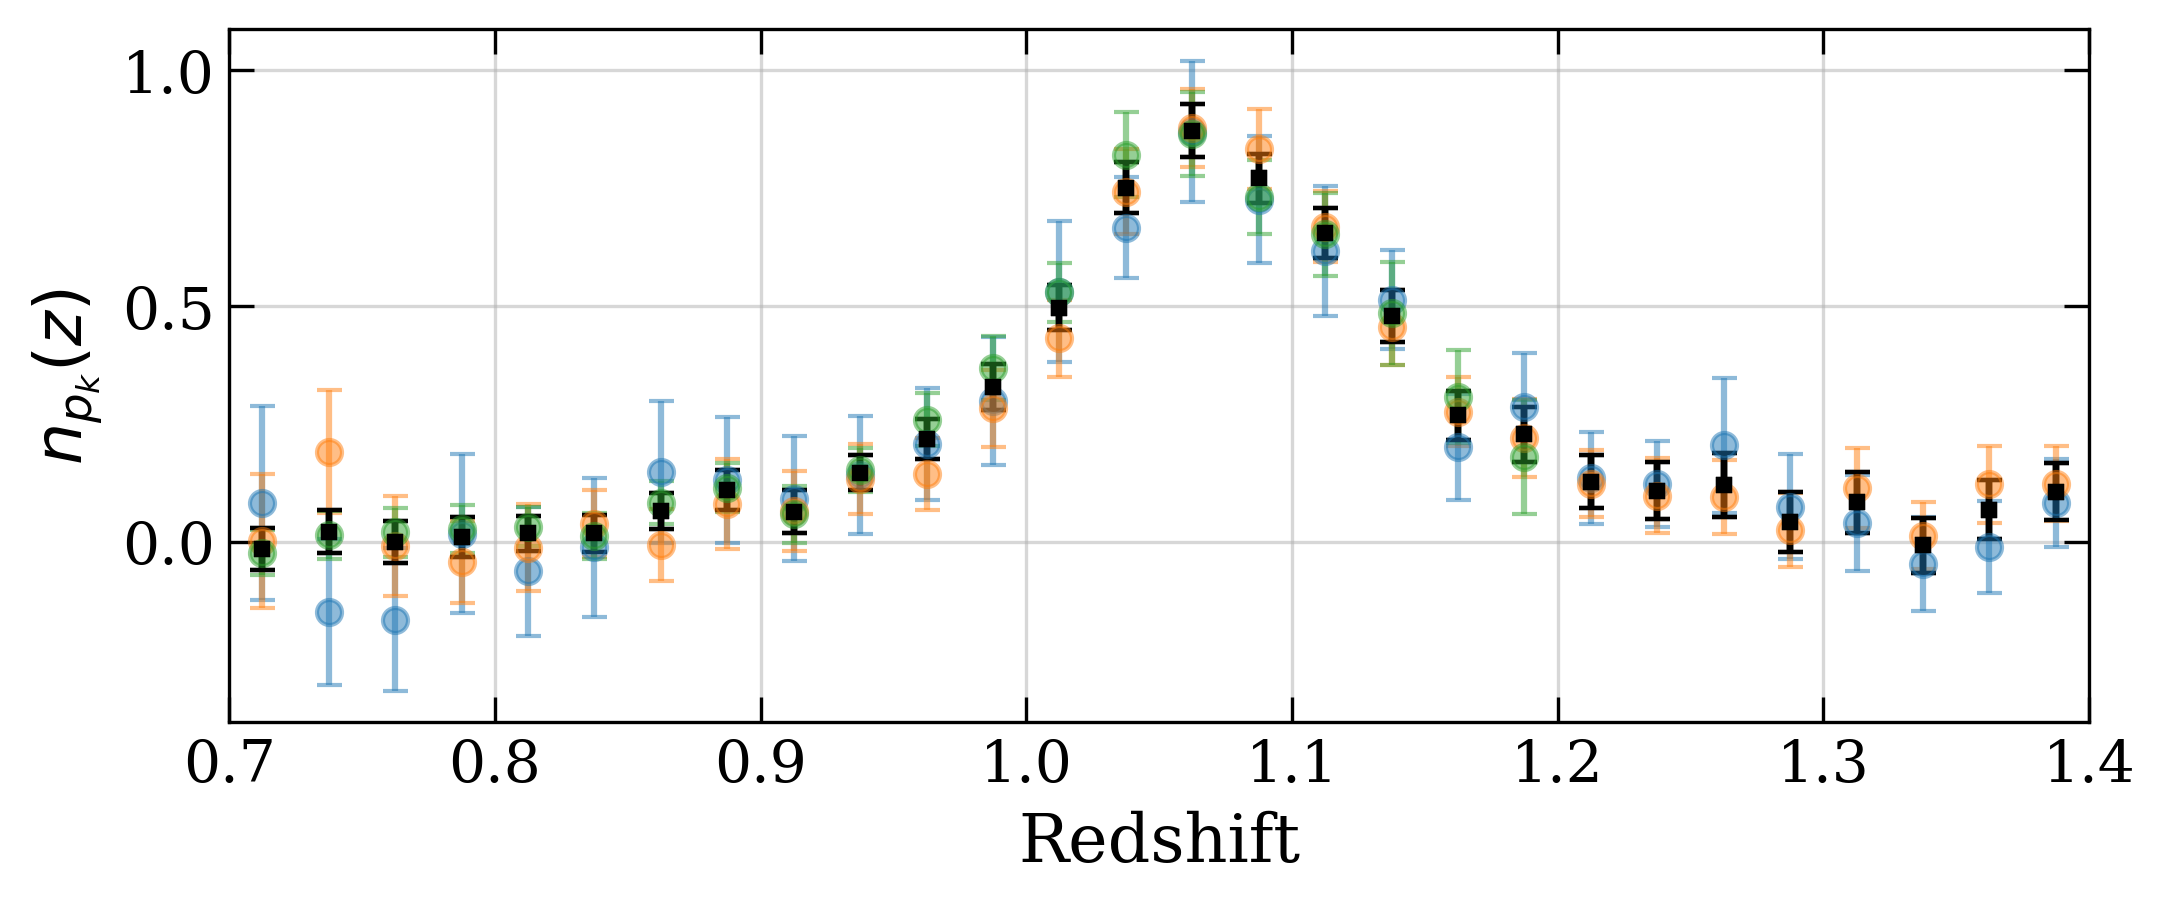

In [36]:
plt.figure(figsize=(8, 3))
colors = plt.get_cmap("tab10")
bin_tomo = 11
current_bin_values = data[str(bin_tomo)]
for index, (key, value) in enumerate(current_bin_values.items()):
    if len(current_bin_values[key]) == 0:
        print(f"No data for {key} in tomo bin {bin_tomo}")
        continue
    z, vals, errs = zip(*current_bin_values[key])
    plt.errorbar(
        z,
        vals,
        errs,
        label=tracer_trad[key],
        capsize=3,
        alpha=0.5,
        fmt="o",
        color=colors(index),
    )
    plt.errorbar(
        merged_data[str(bin_tomo)][0],
        merged_data[str(bin_tomo)][1],
        merged_data[str(bin_tomo)][2],
        fmt="s",
        color="black",
        label=f"Merged {tracer_trad[key]}",
        markersize=3,
        alpha=1,
        capsize=3,
    )
plt.xlim(bin_tomo * 0.1 - 0.4, bin_tomo * 0.1 + 0.3)
plt.grid(True)
plt.xlabel("Redshift")
plt.ylabel(r"$n_{p_k}(z)$")

In [37]:
importlib.reload(inference)
merged_bins = {}
for bin_key, bin_values in data.items():
    zm, valsm, errsm = [], [], []
    for key, value in bin_values.items():
        if len(value) == 0:
            print(f"No data for {key} in tomo bin {bin_key}")
            continue
        z, vals, errs = zip(*value)
        zm.append(np.asarray(z))
        valsm.append(np.asarray(vals))
        errsm.append(np.asarray(errs))
    z_pz, n_pz, n_pz_errs = inference.merge_results(zm, valsm, errsm)
    # will be normalized back again after sampling.
    merged_bins[bin_key] = (list(z_pz), list(n_pz), list(n_pz_errs))

with open(
    f"{ROOT}/results/n_pk_z/merged_bins_{scale_cut[0]}_{scale_cut[1]}_{version}.json",
    "w",
) as f:
    json.dump(merged_bins, f)

No data for ELGnotqso in tomo bin 1
No data for ELGnotqso in tomo bin 2
No data for ELGnotqso in tomo bin 3
No data for ELGnotqso in tomo bin 4
No data for ELGnotqso in tomo bin 5
No data for ELGnotqso in tomo bin 6
No data for ELGnotqso in tomo bin 7
No data for ELGnotqso in tomo bin 8
No data for ELGnotqso in tomo bin 9


In [38]:
tracer = "Merged"
correction_file_reader = cf.CorrFileReader(path_dictionary["dr2"]["HSC"])
bins_z_photo = inference._get_fine_redshift_bins(
    fr=correction_file_reader, tracer="HSC"
)
vals_z_photo = (bins_z_photo[:-1] + bins_z_photo[1:]) / 2
correction_file_reader = cf.CorrFileReader(path_dictionary["dr2"]["DESI_NGC"])
bins_z_spectro = inference._get_fine_redshift_bins(
    fr=correction_file_reader, tracer="Merged"
)
vals_z_spectro = (bins_z_spectro[:-1] + bins_z_spectro[1:]) / 2

In [39]:
print(f"Scale cuts: {scale_cut}")
vals_z_wdm = np.linspace(0.01, 3, 150)
rp_wdm = np.linspace(scale_cut[0], scale_cut[1], 100)
wdm_values = np.array(
    [ct.w_dm(rp_vals=rp_wdm, z=z, integrate=True) for z in vals_z_wdm]
)
wdm_interpolator = interp.interp1d(
    vals_z_wdm, wdm_values, bounds_error=False, fill_value="extrapolate"
)
wdm_spectro = np.array(
    [ct.w_dm(rp_vals=rp_wdm, z=z, integrate=True) for z in vals_z_spectro]
)
wdm_phot = np.array(
    [ct.w_dm(rp_vals=rp_wdm, z=z, integrate=True) for z in vals_z_photo]
)

Scale cuts: [0.3, 3]


In [40]:
wdm_integrated = []
for z in vals_z_photo:
    # dz_phot = 0.1 (fiducial analysis)
    z_integ = np.linspace(z - 0.05, z + 0.05, 101)
    wdm_integrated.append(np.trapezoid(wdm_interpolator(z_integ), z_integ))

Scale cut : [0.3, 3]
Version : vF


(0.0, 2.5)

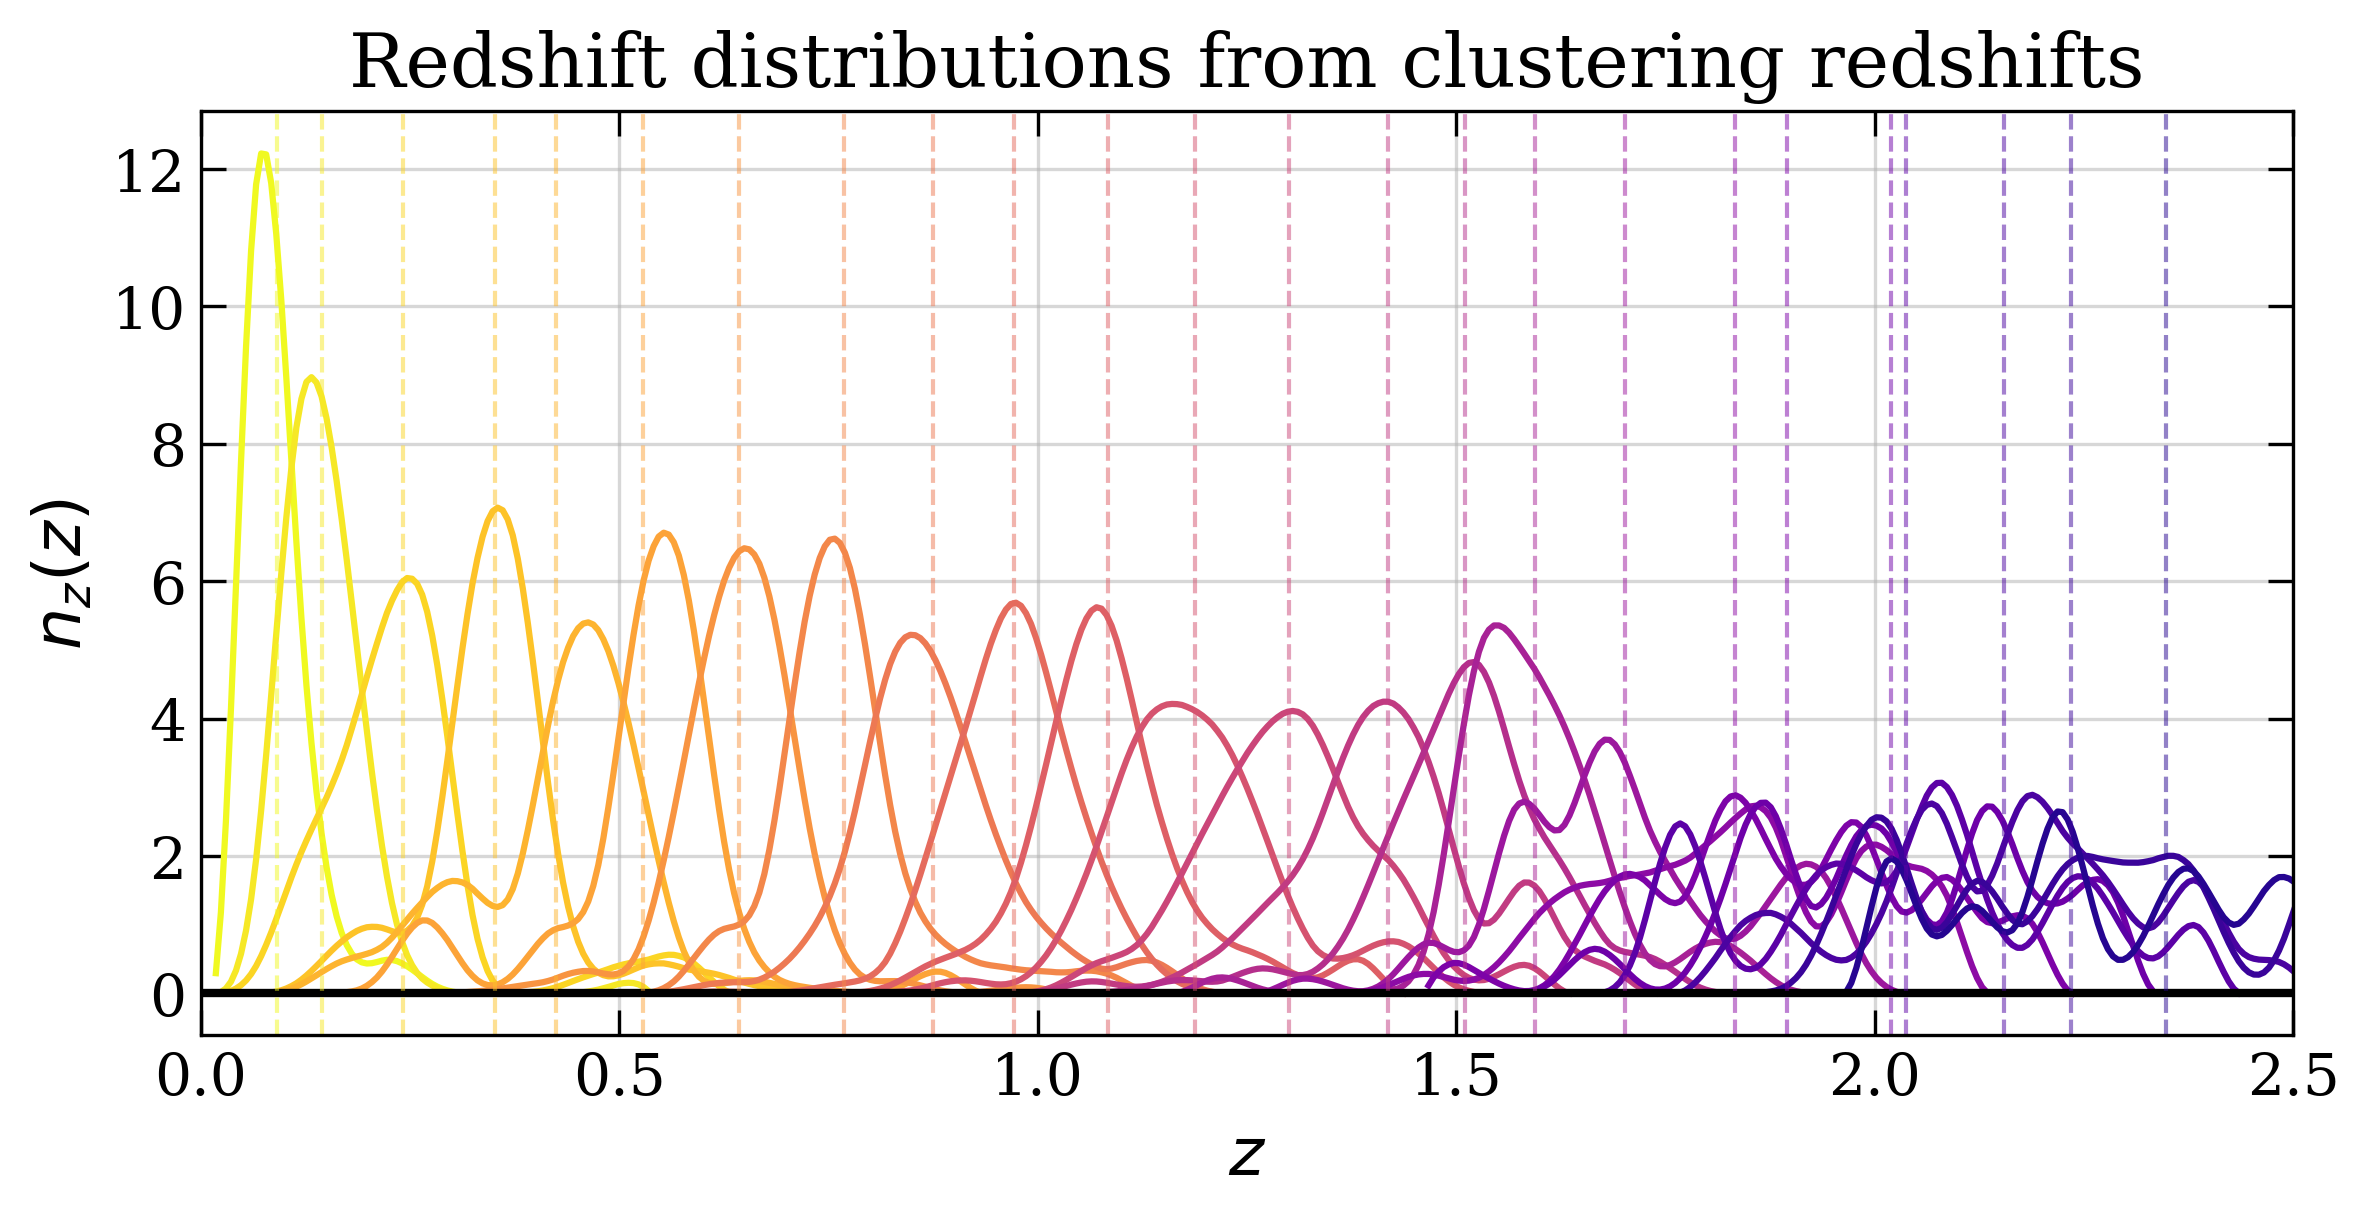

In [41]:
corr_factor = []
corr_factor_err = []
dz = vals_z_spectro[1] - vals_z_spectro[0]
dz_phot = vals_z_photo[1] - vals_z_photo[0]
means_npk = []
print("Scale cut :", scale_cut)
print("Version :", version)

data_galbias = np.load(
    f"{ROOT}/results/photoz_bias_splines_{scale_cut[0]}_{scale_cut[1]}_{version}/tomo_photoz.npz"
)

plt.figure(figsize=(9, 4))
cmap = plt.get_cmap("plasma_r")

for i in range(len(vals_z_photo)):

    redshifts = data_galbias[f"{i+1}/redshifts"]
    nz_med = data_galbias[f"{i+1}/nz_median"]
    uncertainty = (
        data_galbias[f"{i+1}/nz_upper"] - data_galbias[f"{i+1}/nz_lower"]
    ) / 2
    mean = np.trapezoid(redshifts * nz_med, x=redshifts) / np.trapezoid(
        nz_med, x=redshifts
    )
    means_npk.append(mean)

    assert np.isclose(
        np.trapezoid(nz_med, x=redshifts), 1.0
    ), "Redshift distribution is not normalized to 1."

    wdm_inter = wdm_interpolator(redshifts)
    weights_trapz = comb.trapz_weights(redshifts)
    plt.plot(redshifts, nz_med, label=f"Bin {i+1}", color=cmap((i) / len(vals_z_photo)))

    num = wdm_integrated[i] / (dz_phot**2)  # (wdm_phot[i] / dz_phot)
    denom = np.trapezoid(np.multiply(np.array(nz_med) ** 2, wdm_inter), x=redshifts)
    corr = num / denom
    delta_D = np.sqrt(
        np.sum((2 * nz_med * wdm_inter * weights_trapz) ** 2 * uncertainty**2)
    )
    err = num / (denom**2) * delta_D
    corr_factor.append(corr)
    corr_factor_err.append(err)

plt.grid(True)
plt.axhline(0, color="k", lw=2)
for im, m in enumerate(means_npk):
    plt.axvline(m, color=cmap((im) / len(vals_z_photo)), lw=1, ls="--", alpha=0.5)
plt.xlabel(r"$z$")
plt.ylabel(r"$n_z(z)$")
plt.title("Redshift distributions from clustering redshifts")
plt.xlim(0.0, 2.5)

alpha = 0.41590054607117416 ± 0.0038119837752912016
beta  = 0.4304153126089022 ± 0.013780481431903305


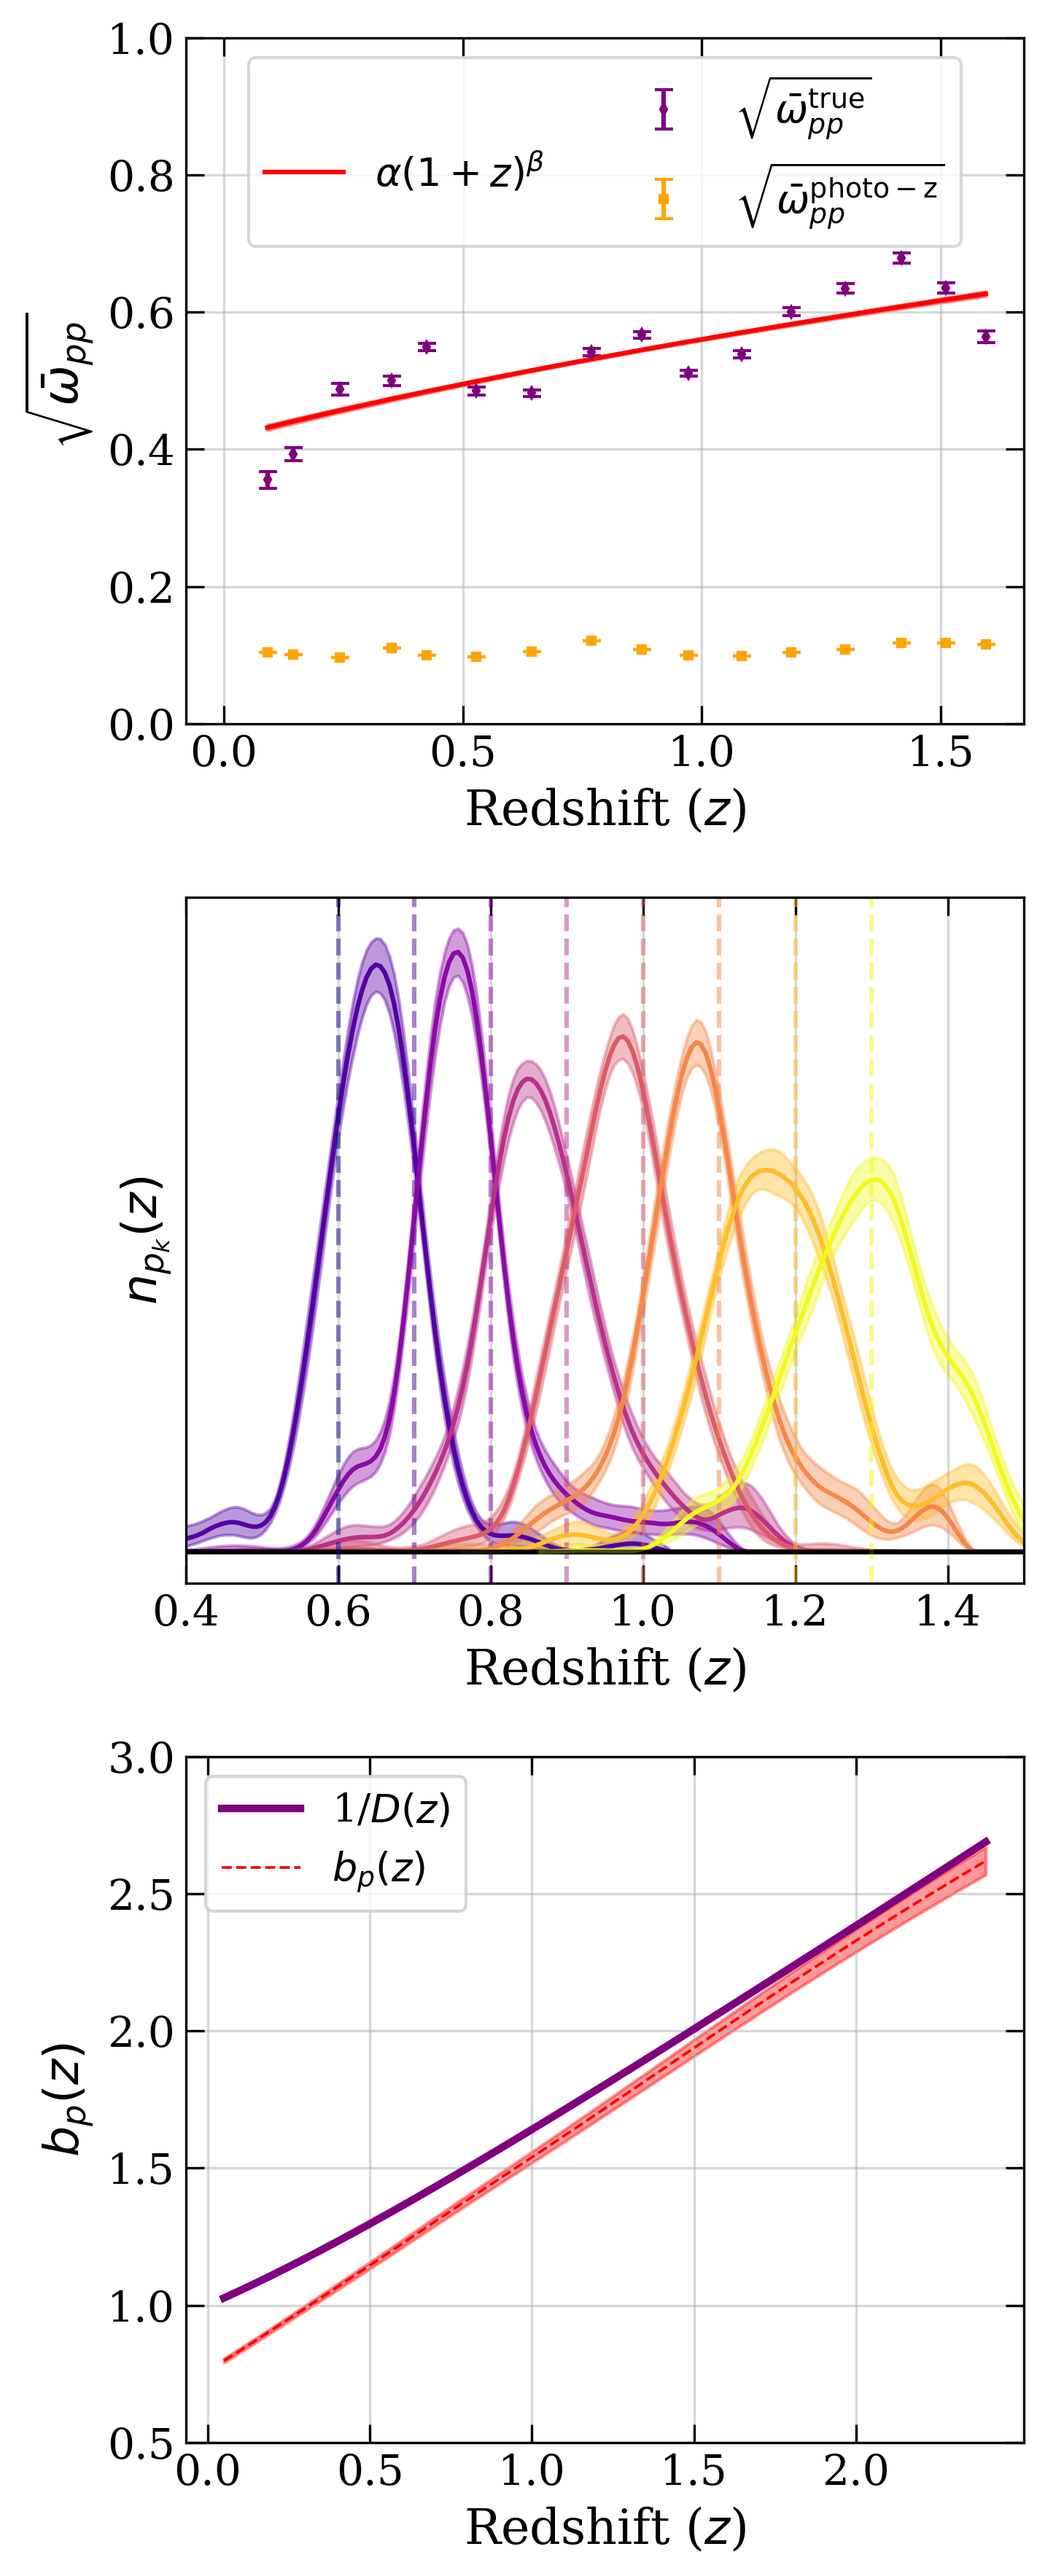

In [42]:
wpp_scaled = []
wpp_err_scaled = []
mask = (vals_z_photo >= 0.0) & (vals_z_photo <= 1.6)
vals_z_photo_m = vals_z_photo[mask]
means_npk_m = np.array(means_npk)[mask]

for i in range(1, len(vals_z_photo) + 1):
    wpp_meas, wpp_err_meas, _ = inference.wpp(
        path=path_dictionary["dr1"]["HSC"],
        scale_cuts=scale_cut,
        bin_index=i,
    )
    wpp_err_scaled.append(wpp_err_meas)
    wpp_scaled.append(wpp_meas)

wpp_m = np.array(wpp_scaled)[mask]
wpp_err_m = np.array(wpp_err_scaled)[mask]
corr_factor_m = np.array(corr_factor)[mask]
corr_factor_err_m = np.array(corr_factor_err)[mask]

errs = comb.combine_error_bars_mult(wpp_m, wpp_err_m, corr_factor_m, corr_factor_err_m)
vals = np.sqrt(wpp_m * corr_factor_m)


def powerlaw_1pz(z, alpha, beta):
    return alpha * (1 + z) ** beta


popt, pcov = opt.curve_fit(
    powerlaw_1pz, means_npk_m, vals, sigma=errs, absolute_sigma=True
)
fit_vals = powerlaw_1pz(means_npk_m, *popt)

z = means_npk_m
alpha, beta = popt

alpha_err, beta_err = np.sqrt(np.diag(pcov))

print(f"alpha = {alpha} ± {alpha_err}")
print(f"beta  = {beta} ± {beta_err}")

J = np.empty((len(z), 2))  # ∂f/∂ jacobian
J[:, 0] = (1 + z) ** beta
J[:, 1] = alpha * (1 + z) ** beta * np.log(1 + z)

fit_sigma = np.sqrt(np.sum(J @ pcov * J, axis=1))

with pm.make_plot("photoz_galaxy_correction", figsize=(5, 12), show=True, nrows=3) as (
    fig,
    axs,
):

    axs[0].fill_between(
        z, fit_vals - fit_sigma, fit_vals + fit_sigma, color="red", alpha=0.5
    )
    axs[0].errorbar(
        z,
        vals,
        errs,
        fmt="d",
        color="purple",
        capsize=3,
        label=r"$\sqrt{\bar{\omega}_{pp}^{\mathrm{true}}}$",
        ms=2.5,
    )
    axs[0].errorbar(
        z,
        wpp_m,
        wpp_err_m,
        fmt="s",
        color="orange",
        capsize=3,
        label=r"$\sqrt{\bar{\omega}_{pp}^{\mathrm{photo-z}}}$",
        ms=2.5,
    )

    axs[0].plot([0, 0], [0, 0], label=" ", alpha=0)
    axs[0].plot(z, fit_vals, color="red", label="$\\alpha(1+z)^\\beta$")
    axs[0].set_xlabel(r"Redshift ($z$)")
    axs[0].set_ylabel(r"$\sqrt{\bar{\omega}_{pp}}$")
    axs[0].grid(True)
    axs[0].legend(loc="upper center", fontsize=13, ncols=2)
    axs[0].set_ylim(0.0, 1.0)

    cmap = plt.get_cmap("plasma")
    col_index = 0
    for i in range(len(vals_z_photo)):
        if i < 6 or i > 12:
            continue
        col_index += 1
        redshifts = data_galbias[f"{i+1}/redshifts"]
        nz_med = data_galbias[f"{i+1}/nz_median"]
        lower = data_galbias[f"{i+1}/nz_lower"]
        upper = data_galbias[f"{i+1}/nz_upper"]

        # columns on the tomographic bins :
        axs[1].axvline(
            x=(i + 1) * 0.1, color=cmap(col_index / 7), linestyle="--", alpha=0.5
        )
        axs[1].fill_between(
            redshifts, lower, upper, color=cmap(col_index / 7), alpha=0.4
        )
        axs[1].plot(
            redshifts, nz_med, color=cmap(col_index / 7), label=f"Photo-z {i+1}"
        )
        axs[1].set_xlim(0.4, 1.5)
        axs[1].set_xlabel(r"Redshift ($z$)")
        axs[1].set_ylabel(r"$n_{p_k}(z)$")
        axs[1].set_yticks([])
        axs[1].axhline(y=0, color="black", linewidth=1.5, alpha=0.7)
    axs[1].axvline(x=(6) * 0.1, color=cmap(0), linestyle="--", alpha=0.5)

    zv = np.linspace(0.05, 2.4, 150)
    bias = (
        lambda z: alpha * (1 + z) ** beta * np.sqrt(0.1 / wdm_interpolator(z))
    )  # dz=0.1
    bias_err = bias(zv) * np.sqrt(
        (alpha_err / alpha) ** 2 + (beta_err * np.log(1 + zv)) ** 2
    )
    gf = ccl.background.growth_factor(ct.COSMO_ccl, a=1 / (1 + zv))
    axs[2].plot(zv, 1 / gf, color="purple", label=r"1/$D(z)$", linewidth=2.5)
    axs[2].fill_between(
        zv, bias(zv) - bias_err, bias(zv) + bias_err, color="red", alpha=0.4
    )
    axs[2].plot(
        zv,
        bias(zv),
        color="red",
        label=r"$b_p(z)$",
        linestyle="--",
        linewidth=0.9,
        alpha=1,
    )
    axs[2].set_xticks(np.arange(0, 2.5, 0.5))
    axs[2].set_yticks([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5])
    axs[2].set_ylim(0.5, 3)
    axs[2].set_xlabel(r"Redshift ($z$)")
    axs[2].set_ylabel(r"$b_p(z)$")
    axs[2].legend(loc="upper left", fontsize=13)